V21 Aufgabe 1

In [38]:
import numpy as np
import uncertainties as unc

In [39]:
I = unc.ufloat(0.75, 0.01)  # Stromstärke in A
t = unc.ufloat(1800, 30)  # Zeit in s
m_an_vor = unc.ufloat(115.2190, 0.001) 
m_an_nach = unc.ufloat(114.7310, 0.01) 
m_kath_vor = unc.ufloat(104.4710, 0.001)
m_kath_nach = unc.ufloat(104.9420, 0.01)

m_an = m_an_vor - m_an_nach
m_kath = m_kath_nach - m_kath_vor

F_an = (I * t * 63.546/ (2 * m_an))
F_kath = (I * t * 63.546/ (2 * m_kath))

print(f'Q = {I * t:.3uP}')
print(f'{m_an=:.3uP}')
print(f'{m_kath=:.3uP}')
print(f"Faraday-Konstante Anode: {F_an:.3uP}")
print(f"Faraday-Konstante Kathode: {F_kath:.3uP}")

print(f'Mittelwert der Faraday-Konstante: {(F_an + F_kath)/2:.3uP}')

Q = 1350.0±28.8
m_an=0.4880±0.0100
m_kath=0.4710±0.0100
Faraday-Konstante Anode: (8.790±0.261)×10⁴
Faraday-Konstante Kathode: (9.107±0.275)×10⁴
Mittelwert der Faraday-Konstante: (8.948±0.233)×10⁴


Abweichung

In [40]:
F_lit = 96485.33212


simga_an = abs(F_an.n - F_lit) / F_an.s
simga_kath = abs(F_kath.n - F_lit) / F_kath.s

print(f'{simga_an=:.2f}')
print(f'{simga_kath=:.2f}')


simga_an=3.29
simga_kath=1.97


[10. 11. 12. 13. 14. 15. 16. 17. 18. 19. 20. 21. 22. 23. 24. 25.]


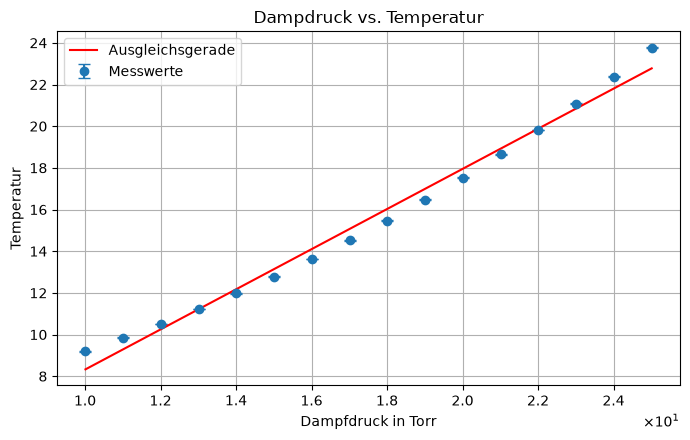

m = 0.9629
b = -1.2981


In [41]:
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

# Beispiel: Ausgleichsgerade mit x-Achse in 10^-3
x = np.linspace(10, 25, 16)
print(x)
y = np.array([9.20, 9.84, 10.51, 11.23, 11.98, 12.78, 13.63, 14.53, 15.47, 16.47, 17.53, 18.65, 19.82, 21.07, 22.38, 23.76])
err_y = np.full_like(y, 0.02)


def linear(x, m, b):
    return m * x + b

popt, pcov = curve_fit(linear, x, y, sigma=err_y, absolute_sigma=True)

x_fit = np.linspace(x.min(), x.max(), 200)
y_fit = linear(x_fit, *popt)

plt.figure(figsize=(7, 4.5))
plt.errorbar(x, y, yerr=err_y, fmt='o', capsize=4, label='Messwerte')
plt.plot(x_fit, y_fit, color='red', label='Ausgleichsgerade')

plt.xlabel('Dampfdruck in Torr')
plt.ylabel('Temperatur')
plt.title('Dampdruck vs. Temperatur')
plt.grid(True)
plt.legend()

ax = plt.gca()
ax.ticklabel_format(axis='x', style='sci', scilimits=(0, 0), useMathText=True)
plt.tight_layout()
plt.show()

print(f'm = {popt[0]:.4f}')
print(f'b = {popt[1]:.4f}')



In [42]:
T = unc.ufloat(22.5, 1.5)
print(linear(T, *popt))

20.4+/-1.4


In [43]:
p_Dampf = linear(T, *popt) * 1.33322  # Torr in mbar
print(f'{p_Dampf=:.4uP}')

p_Luft = unc.ufloat(1009.7, 0.2)

p = p_Luft + 0.9*p_Dampf
p

p_Dampf=27.155±1.926


1034.1392313191598+/-1.7446220362128806

In [44]:
p_0 = 1013.25
T_0 = 273.15
T_K = T + 273.15
V_Mol_0 = 22.414

V_Mol = (p_0/p) * (T_K/T_0) * V_Mol_0
V_Mol

23.77024426354587+/-0.08089395076577847

In [45]:
V_H2 = unc.ufloat(45.6, 0.2)*1e-3  

n = V_H2 / V_Mol
print(f'{n=:.4e}')

n=(1.9184+/-0.0106)e-03


In [46]:
I_v = unc.ufloat(0.85, 0.01)  
t_v = unc.ufloat(403, 3)


F = I_v * t_v /(2 * n)
print(f'{F=:.4e}')

F=(8.9282+/-0.1338)e+04


Abweichung

In [47]:
(F.n - F_lit)/F.s

-5.3831822014814295